# Early Sepsis Prediction — PhysioNet/CinC 2019 Challenge

This notebook builds a **patient-level sepsis risk classifier** on the [PhysioNet/Computing in Cardiology Challenge 2019](https://physionet.org/content/challenge-2019/1.0.0/) dataset, using and comparing **Random Forest**, **XGBoost**, **KNN**, **Logistic Regression**, and **SVM**, wrapped in a single deployable `sklearn` `Pipeline`.

**Task.** Each ICU patient has an hourly time series of vital signs, laboratory values, and demographics, plus an hourly `SepsisLabel` (1 if the patient meets the Sepsis-3 clinical criteria at that hour, per the challenge's retrospective labeling, 0 otherwise). We aggregate each patient's stay into a single feature vector and predict **whether the patient develops sepsis at any point during their ICU stay**.

> **Note on granularity:** the original challenge task is *hourly* (predict sepsis onset up to 6h in advance, hour by hour). Here we instead solve a **per-patient** classification problem — one row per patient — which is simpler to model, easier to deploy as a risk-scoring pipeline, and a natural fit for tree-based models like Random Forest / XGBoost. See the "Limitations & Next Steps" section at the end for how this differs from the official challenge task.

### Data format
- Data is distributed as one **pipe-separated (`.psv`)** file per patient (e.g. `p000001.psv`), split across `training_setA/` and `training_setB/`.
- Each file has **hourly rows** and **40 columns**: 8 vital signs, 26 laboratory values, 6 demographic/ICU columns, and the `SepsisLabel` target.
- Missingness is extremely high for labs (many are only drawn once every several hours or not at all) — this drives a lot of our feature engineering below.

### How to use this notebook
1. Upload the PhysioNet 2019 data (the `training_setA` / `training_setB` folders, or a flat folder of `.psv` files, or the official `.zip`) to `/mnt/user-data/uploads/` (or update `DATA_DIR` below).
2. Run all cells top to bottom.
3. The final trained pipeline (preprocessing + model bundled together) is exported to `/mnt/user-data/outputs/sepsis_pipeline.joblib`, ready for inference on new patients.


## 1. Setup & Configuration

In [1]:
!unzip Data.zip

Streaming output truncated to the last 5000 lines.
  inflating: Data/training_setB/training_setB/p115001.psv  
  inflating: Data/training_setB/training_setB/p115002.psv  
  inflating: Data/training_setB/training_setB/p115003.psv  
  inflating: Data/training_setB/training_setB/p115004.psv  
  inflating: Data/training_setB/training_setB/p115005.psv  
  inflating: Data/training_setB/training_setB/p115006.psv  
  inflating: Data/training_setB/training_setB/p115007.psv  
  inflating: Data/training_setB/training_setB/p115008.psv  
  inflating: Data/training_setB/training_setB/p115009.psv  
  inflating: Data/training_setB/training_setB/p115010.psv  
  inflating: Data/training_setB/training_setB/p115011.psv  
  inflating: Data/training_setB/training_setB/p115012.psv  
  inflating: Data/training_setB/training_setB/p115013.psv  
  inflating: Data/training_setB/training_setB/p115014.psv  
  inflating: Data/training_setB/training_setB/p115015.psv  
  inflating: Data/training_setB/training_setB/p11

In [2]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

from xgboost import XGBClassifier
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# --- Configuration -----------------------------------------------------
# Point this at wherever you uploaded the PhysioNet data. The loader below
# searches recursively for *.psv files, so training_setA/training_setB
# subfolders (the standard distribution layout) work automatically.
DATA_DIR = "/content/Data"
OUTPUT_DIR = "/content/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VITALS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']

LABS = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
        'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
        'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
        'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
        'Fibrinogen', 'Platelets']

DEMOGRAPHICS = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']

NUMERIC_TIMESERIES = VITALS + LABS

print(f"{len(VITALS)} vital signs, {len(LABS)} lab values, {len(DEMOGRAPHICS)} demographic columns")


8 vital signs, 26 lab values, 6 demographic columns


## 2. Data Loading

We recursively find every `.psv` file under `DATA_DIR`, read it, and stitch an hourly "long" table together with a `PatientID` column derived from the filename (e.g. `p000001.psv` → `p000001`).

In [3]:
def find_psv_files(data_dir):
    files = sorted(glob.glob(os.path.join(data_dir, "**", "*.psv"), recursive=True))
    return files


def load_raw_hourly(data_dir):
    files = find_psv_files(data_dir)
    if len(files) == 0:
        raise FileNotFoundError(
            f"No .psv files found under '{data_dir}'.\n"
            "Upload the PhysioNet 2019 Challenge data (training_setA / training_setB "
            "folders, or a flat folder of .psv files) to this location, or update DATA_DIR above.\n"
            "Dataset: https://physionet.org/content/challenge-2019/1.0.0/"
        )
    frames = []
    for f in files:
        df = pd.read_csv(f, sep='|')
        df['PatientID'] = os.path.splitext(os.path.basename(f))[0]
        frames.append(df)
    raw = pd.concat(frames, ignore_index=True)
    return raw


raw = load_raw_hourly(DATA_DIR)
print(f"Loaded {raw['PatientID'].nunique():,} patients, {len(raw):,} hourly rows, {raw.shape[1]} columns")
raw.head()


Loaded 40,336 patients, 1,552,210 hourly rows, 42 columns


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,PatientID
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001


## 3. Initial Inspection

In [4]:
print("Columns:", list(raw.columns))
print()
raw.info()


Columns: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'PatientID']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 42 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   HR                1398811 non-null  float64
 1   O2Sat             1349474 non-null  float64
 2   Temp              525226 non-null   float64
 3   SBP               1325945 non-null  float64
 4   MAP               1358940 non-null  float64
 5   DBP               1065656 non-null  float64
 6   Resp              1313875 non-null  float6

In [5]:
raw.describe().T.style.background_gradient(cmap='Blues', axis=0)


,count,mean,std,min,25%,50%,75%,max
HR,1398811.000000,84.581443,17.325242,20.000000,72.000000,83.500000,95.500000,280.000000
O2Sat,1349474.000000,97.193955,2.936924,20.000000,96.000000,98.000000,99.500000,100.000000
Temp,525226.000000,36.977228,0.770014,20.900000,36.500000,37.000000,37.500000,50.000000
SBP,1325945.000000,123.750465,23.231556,20.000000,107.000000,121.000000,138.000000,300.000000
MAP,1358940.000000,82.400100,16.341750,20.000000,71.000000,80.000000,92.000000,300.000000
DBP,1065656.000000,63.830556,13.956010,20.000000,54.000000,62.000000,72.000000,300.000000
Resp,1313875.000000,18.726498,5.098194,1.000000,15.000000,18.000000,21.500000,100.000000
EtCO2,57636.000000,32.957657,7.951662,10.000000,28.000000,33.000000,38.000000,100.000000
BaseExcess,84145.000000,-0.689919,4.294297,-32.000000,-3.000000,0.000000,1.000000,100.000000
HCO3,65028.000000,24.075481,4.376504,0.000000,22.000000,24.000000,26.800000,55.000000


## 4. Missing Data Analysis

Lab values in ICU time series are drawn sparingly (only when clinically indicated), so we expect very high missingness for most lab columns and much lower missingness for vitals (continuously monitored). This directly informs our feature engineering: we'll keep a **"was this ever measured / how often"** signal in addition to summary statistics, since missingness itself can be informative (e.g., a clinician ordering more frequent labs may reflect concern about a sick patient).

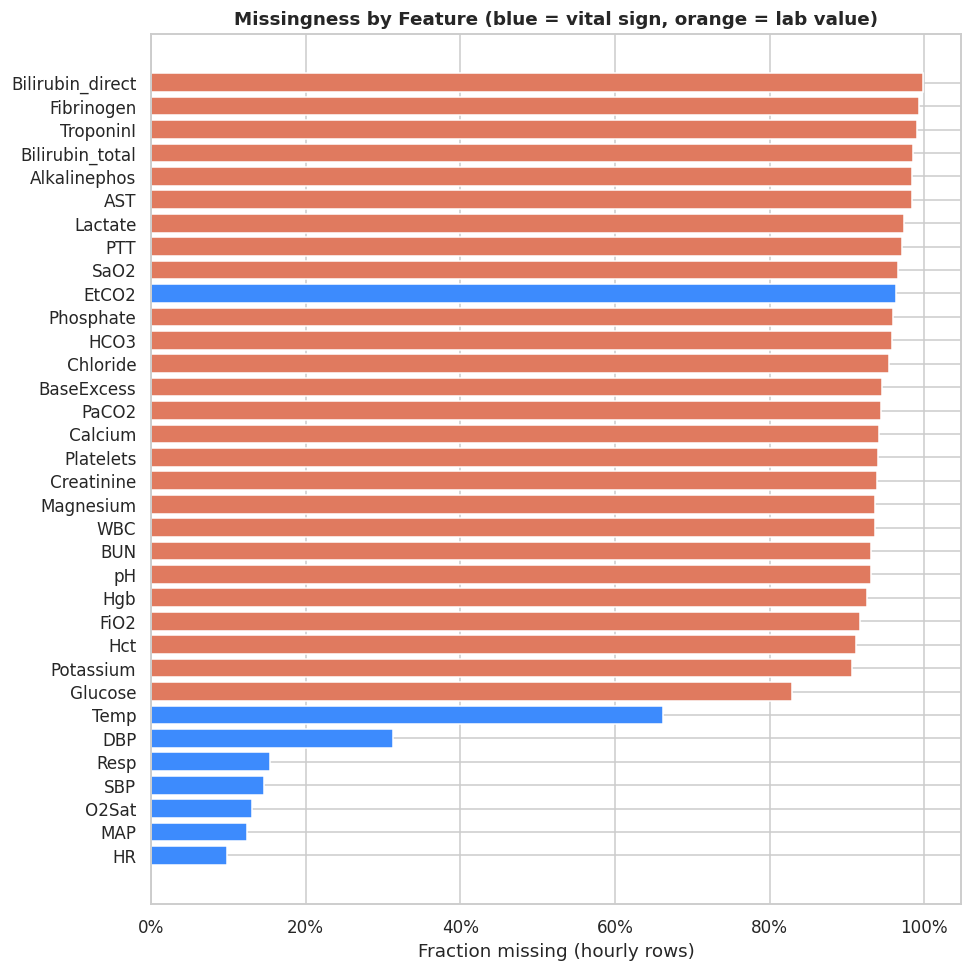

In [6]:
missing_frac = raw[NUMERIC_TIMESERIES].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 9))
colors = ['#e07a5f' if c in LABS else '#3d8bfd' for c in missing_frac.index]
ax.barh(missing_frac.index, missing_frac.values, color=colors)
ax.set_xlabel("Fraction missing (hourly rows)")
ax.set_title("Missingness by Feature (blue = vital sign, orange = lab value)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.invert_yaxis()
plt.tight_layout()
plt.show()


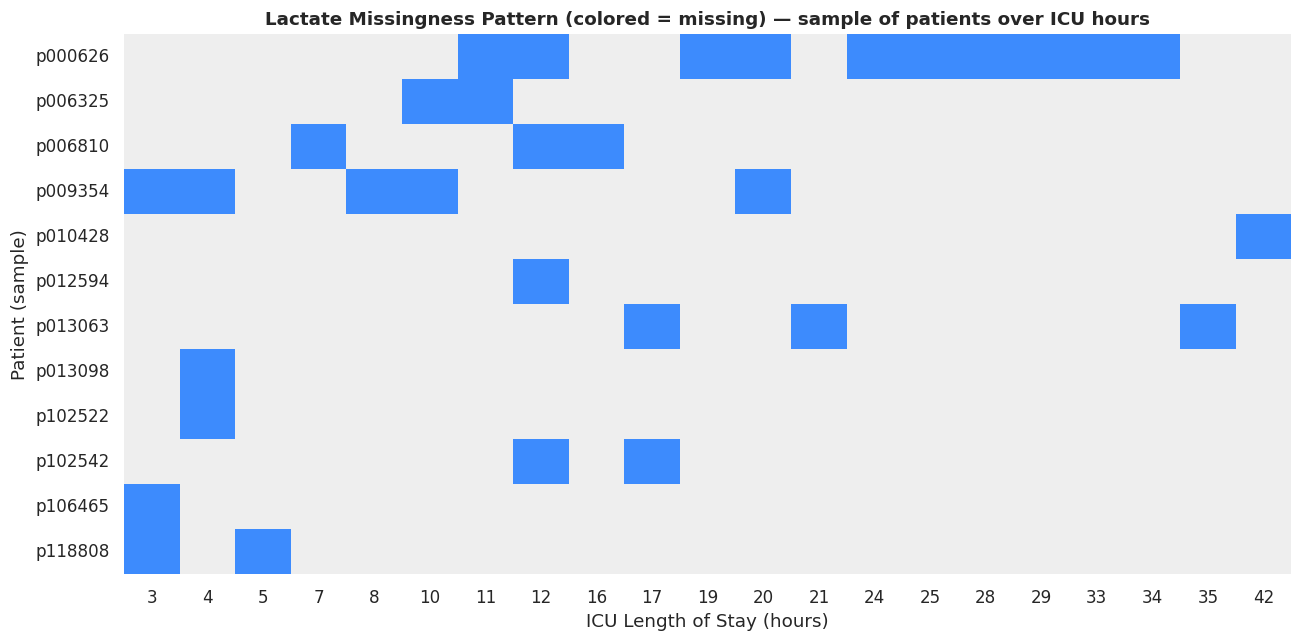

In [7]:
# Missingness heatmap for a sample of patients (visualizes patterns over time)
sample_patients = raw['PatientID'].drop_duplicates().sample(min(40, raw['PatientID'].nunique()), random_state=RANDOM_STATE)
sample = raw[raw['PatientID'].isin(sample_patients)]

pivot = sample.pivot_table(index='PatientID', columns='ICULOS', values='Lactate', aggfunc='first')
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot.isna(), cmap=['#3d8bfd', '#eeeeee'], cbar=False, ax=ax)
ax.set_title("Lactate Missingness Pattern (colored = missing) — sample of patients over ICU hours")
ax.set_xlabel("ICU Length of Stay (hours)")
ax.set_ylabel("Patient (sample)")
plt.tight_layout()
plt.show()


## 5. Target Definition & Class Balance

We define the **patient-level target** as: did this patient ever have `SepsisLabel == 1` at any hour during their stay? This is the label we'll predict from the aggregated feature vector.

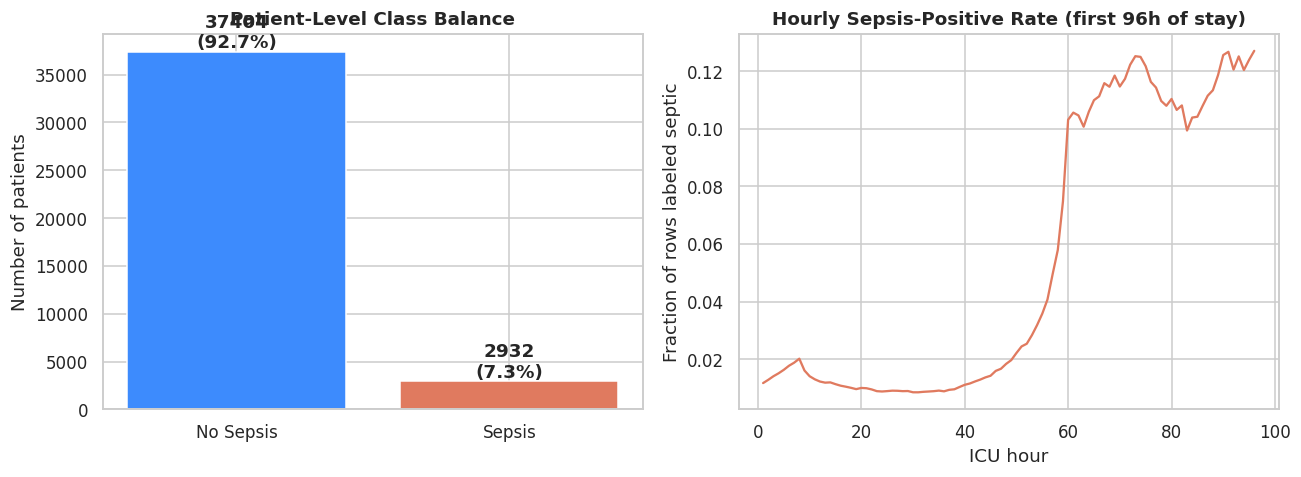

Class imbalance ratio (negative:positive) = 37404:2932 ≈ 12.8:1


In [8]:
patient_label = raw.groupby('PatientID')['SepsisLabel'].max().rename('SepsisEver')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

counts = patient_label.value_counts().sort_index()
axes[0].bar(['No Sepsis', 'Sepsis'], counts.values, color=['#3d8bfd', '#e07a5f'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.values) * 0.01, f"{v}\n({v/counts.sum():.1%})", ha='center', fontweight='bold')
axes[0].set_title("Patient-Level Class Balance")
axes[0].set_ylabel("Number of patients")

hourly_rate = raw.groupby('ICULOS')['SepsisLabel'].mean()
axes[1].plot(hourly_rate.index[:96], hourly_rate.values[:96], color='#e07a5f')
axes[1].set_title("Hourly Sepsis-Positive Rate (first 96h of stay)")
axes[1].set_xlabel("ICU hour")
axes[1].set_ylabel("Fraction of rows labeled septic")

plt.tight_layout()
plt.show()

print(f"Class imbalance ratio (negative:positive) = {(patient_label==0).sum()}:{(patient_label==1).sum()} "
      f"≈ {(patient_label==0).sum()/max((patient_label==1).sum(),1):.1f}:1")


## 6. Exploratory Data Analysis

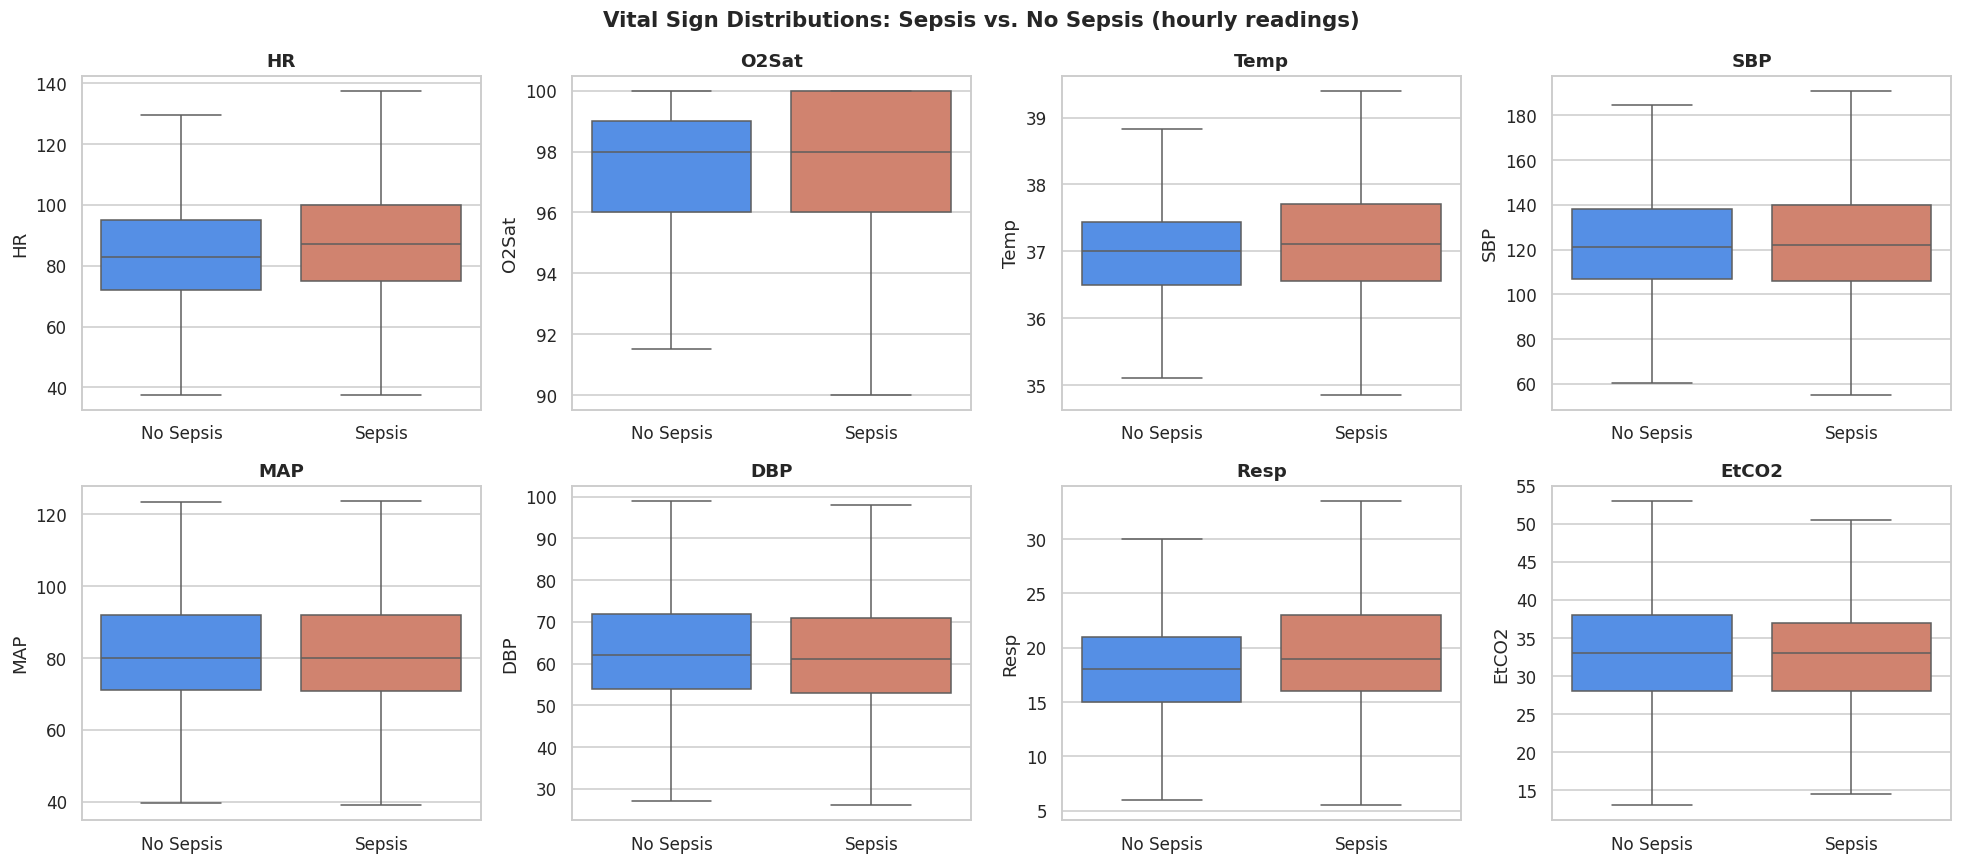

In [9]:
# Attach patient-level label back onto the hourly table for group comparisons
raw_labeled = raw.merge(patient_label, on='PatientID')

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, vital in zip(axes.flat, VITALS):
    sns.boxplot(data=raw_labeled, x='SepsisEver', y=vital, hue='SepsisEver', ax=ax, showfliers=False,
                palette={0: '#3d8bfd', 1: '#e07a5f'}, legend=False)
    ax.set_xticklabels(['No Sepsis', 'Sepsis'])
    ax.set_title(vital)
    ax.set_xlabel("")
fig.suptitle("Vital Sign Distributions: Sepsis vs. No Sepsis (hourly readings)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


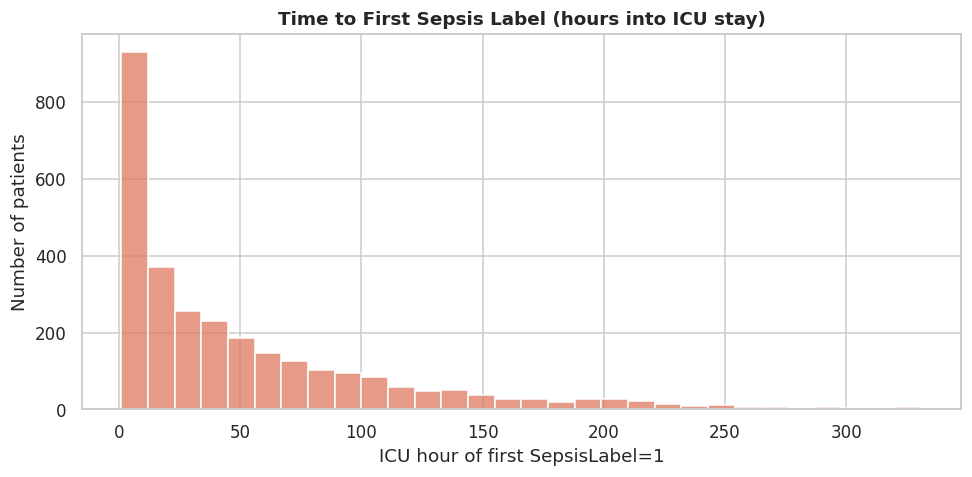

count    2932.000000
mean       50.896317
std        59.363675
min         1.000000
25%         7.000000
50%        29.000000
75%        73.000000
max       331.000000
Name: ICULOS, dtype: float64


In [10]:
# Time-to-onset: among septic patients, how many hours into their stay does sepsis first appear?
onset_hours = (
    raw[raw['SepsisLabel'] == 1]
    .groupby('PatientID')['ICULOS']
    .min()
)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(onset_hours, bins=30, color='#e07a5f', ax=ax)
ax.set_title("Time to First Sepsis Label (hours into ICU stay)")
ax.set_xlabel("ICU hour of first SepsisLabel=1")
ax.set_ylabel("Number of patients")
plt.tight_layout()
plt.show()
print(onset_hours.describe())


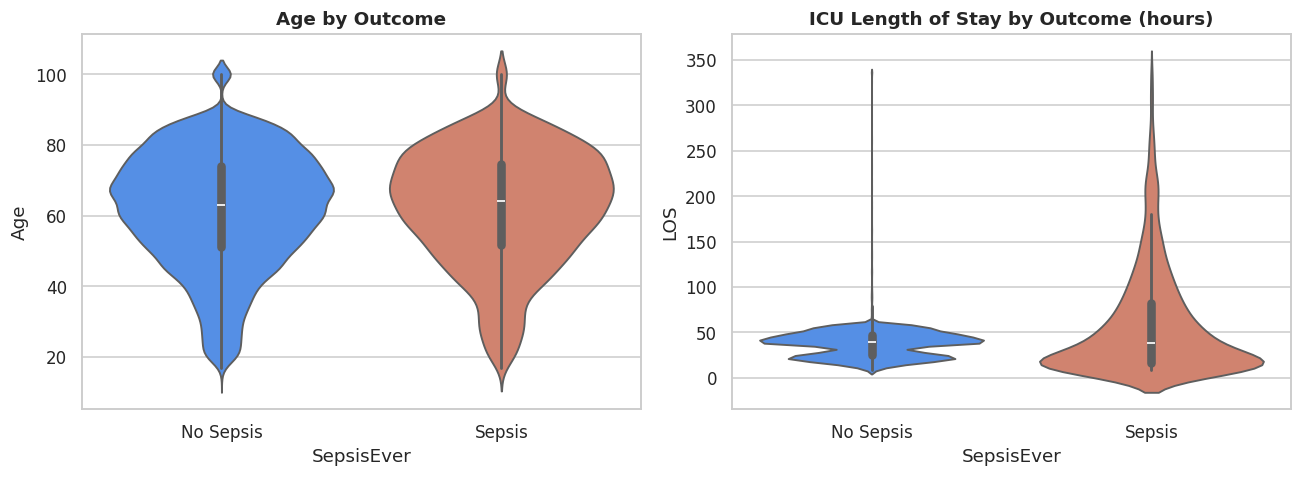

In [11]:
# Age & ICU length-of-stay by outcome
patient_demo = raw.groupby('PatientID').agg(Age=('Age', 'first'), LOS=('ICULOS', 'max')).join(patient_label)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.violinplot(data=patient_demo, x='SepsisEver', y='Age', hue='SepsisEver', ax=axes[0], palette={0: '#3d8bfd', 1: '#e07a5f'}, legend=False)
axes[0].set_xticklabels(['No Sepsis', 'Sepsis'])
axes[0].set_title("Age by Outcome")

sns.violinplot(data=patient_demo, x='SepsisEver', y='LOS', hue='SepsisEver', ax=axes[1], palette={0: '#3d8bfd', 1: '#e07a5f'}, legend=False)
axes[1].set_xticklabels(['No Sepsis', 'Sepsis'])
axes[1].set_title("ICU Length of Stay by Outcome (hours)")
plt.tight_layout()
plt.show()


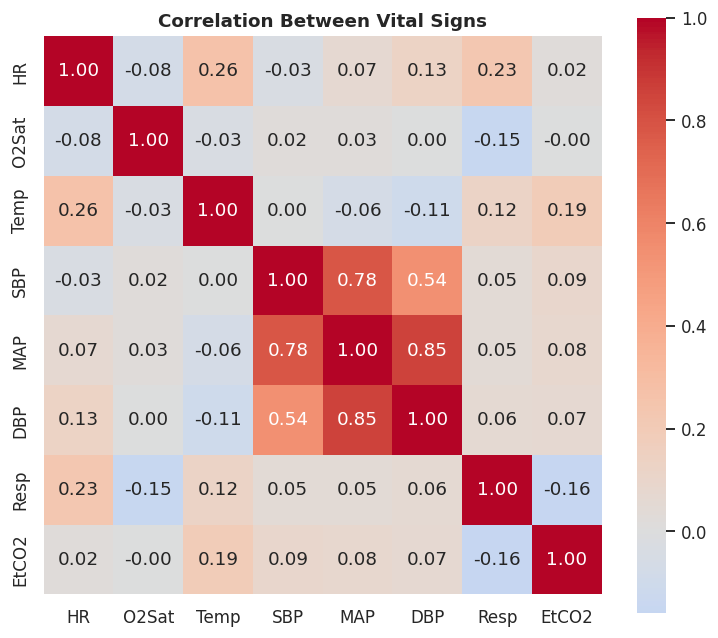

In [12]:
# Correlation among vital signs (hourly level)
fig, ax = plt.subplots(figsize=(7, 6))
corr = raw[VITALS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation Between Vital Signs")
plt.tight_layout()
plt.show()


## 7. Feature Engineering: Hourly Time Series → Per-Patient Feature Vector

For each patient we collapse their hourly time series into a single row of summary statistics per numeric column:

- **`_mean`, `_std`, `_min`, `_max`** — central tendency and spread over the stay
- **`_last`** — most recent recorded value (most clinically relevant for "current state")
- **`_missing_frac`** — fraction of hours where this value was *not* recorded (captures monitoring intensity, which is itself informative)

Plus static/demographic features (`Age`, `Gender`, `HospAdmTime`, ICU length of stay) and two simple derived clinical scores:

- **Shock Index** = mean HR / mean SBP (elevated in early sepsis/shock)
- **Pulse Pressure** = mean SBP − mean DBP

This produces one row per patient — the modeling unit for all five classifiers below.

In [13]:
def aggregate_patient_features(raw, numeric_cols):
    # Vectorized per-patient aggregation.
    #
    # Uses native groupby aggregations (computed in C across all patients at
    # once) instead of groupby().apply() with a per-group Python function --
    # the latter is dramatically slower at scale (one Python call per patient)
    # and does not vectorize across columns.
    gb = raw.groupby('PatientID')

    stats = gb[numeric_cols].agg(['mean', 'std', 'min', 'max'])
    stats.columns = [f'{col}_{stat}' for col, stat in stats.columns]

    # .last() returns the last *non-null* value per group per column --
    # exactly the "most recent recorded value" semantics we want.
    last_vals = gb[numeric_cols].last().add_suffix('_last')

    missing_frac = raw[numeric_cols].isna().groupby(raw['PatientID']).mean().add_suffix('_missing_frac')

    demo = gb.agg(
        Age=('Age', 'first'),
        Gender=('Gender', 'first'),
        HospAdmTime=('HospAdmTime', 'first'),
        ICU_LOS=('ICULOS', 'max'),
        SepsisLabel=('SepsisLabel', 'max'),
    )

    # Build all pieces first, then concat once (avoids the "highly
    # fragmented DataFrame" perf warning from repeated column inserts).
    out = pd.concat([stats, last_vals, missing_frac, demo], axis=1)
    out['ShockIndex'] = out['HR_mean'] / out['SBP_mean'].replace(0, np.nan)
    out['PulsePressure'] = out['SBP_mean'] - out['DBP_mean']
    out['SepsisLabel'] = out['SepsisLabel'].astype(int)
    return out.reset_index()


patient_df = aggregate_patient_features(raw, NUMERIC_TIMESERIES)
print(f"Patient-level feature table: {patient_df.shape[0]} patients x {patient_df.shape[1]} columns")
patient_df.head()


Patient-level feature table: 40336 patients x 212 columns


,PatientID,HR_mean,HR_std,HR_min,HR_max,O2Sat_mean,O2Sat_std,O2Sat_min,O2Sat_max,Temp_mean,...,WBC_missing_frac,Fibrinogen_missing_frac,Platelets_missing_frac,Age,Gender,HospAdmTime,ICU_LOS,SepsisLabel,ShockIndex,PulsePressure
0,p000001,101.571429,9.594378,76.0,117.0,91.477273,3.460667,85.0,100.0,36.778000,...,0.962963,1.0,0.962963,83.14,0,-0.03,54,0,0.800976,NaN
1,p000002,60.954545,8.144395,54.0,94.0,97.000000,2.138090,94.0,100.0,36.165000,...,0.956522,1.0,0.956522,75.91,0,-98.60,23,0,0.446227,92.533333
2,p000003,79.611111,6.714036,68.0,93.0,95.431818,1.655122,91.0,99.0,37.609375,...,0.937500,1.0,0.937500,45.82,0,-1195.71,48,0,0.568515,85.640476
3,p000004,102.444444,6.337212,93.0,113.0,98.203704,1.449531,95.5,100.0,36.455000,...,0.965517,1.0,0.931034,65.71,0,-8.77,29,0,0.906434,61.590659
4,p000005,73.916667,7.586697,61.0,88.0,97.500000,0.741620,96.0,99.0,36.992222,...,0.937500,1.0,0.937500,28.09,1,-0.05,49,0,0.556724,NaN


In [14]:
feature_cols = [c for c in patient_df.columns if c not in ('PatientID', 'SepsisLabel')]
X = patient_df[feature_cols]
y = patient_df['SepsisLabel'].astype(int)

print(f"Feature matrix: {X.shape}")
print(f"Overall feature missingness: {X.isna().mean().mean():.1%}")


Feature matrix: (40336, 210)
Overall feature missingness: 30.5%


## 8. Train / Test Split

Since we already collapsed each patient to a single row, a plain stratified split is leakage-free (no patient's hours appear in both sets). We stratify on the target to preserve class balance in both splits.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} patients ({y_train.mean():.1%} septic)")
print(f"Test:  {X_test.shape[0]} patients ({y_test.mean():.1%} septic)")


Train: 32268 patients (7.3% septic)
Test:  8068 patients (7.3% septic)


## 9. Preprocessing Pipeline

We bundle imputation (median — robust to the outliers common in lab values) and scaling into a single `ColumnTransformer`. Scaling isn't strictly necessary for tree models, but keeping it makes the pipeline reusable if you swap in a linear/distance-based model later, and costs nothing here.

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), feature_cols)
    ],
    remainder='drop'
)
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['HR_mean', 'HR_std', 'HR_min', 'HR_max',
                                  'O2Sat_mean', 'O2Sat_std', 'O2Sat_min',
                                  'O2Sat_max', 'Temp_mean', 'Temp_std',
                                  'Temp_min', 'Temp_max', 'SBP_mean', 'SBP_std',
                                  'SBP_min', 'SBP_max', 'MAP_mean', 'MAP_std',
                                  'MAP_min', 'MAP_max', 'DBP_mean', 'DBP_std',
                                  'DBP_min', 'DBP_max', 'Resp_mean', 'Resp_std',
                                  'Resp_min', 'Resp_max', 'EtCO2_mean',
                                  'EtCO2_std', ...])])

## 10. Model 1 — Random Forest

`class_weight='balanced'` reweights the loss to counter the class imbalance we saw in the EDA section, without resorting to resampling.

In [32]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest pipeline trained.")


Random Forest pipeline trained.


## 11. Model 2 — XGBoost

For gradient boosting we counter imbalance via `scale_pos_weight` (ratio of negatives to positives in the training set) rather than `class_weight`, which is XGBoost's native mechanism.

In [18]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)
print("XGBoost pipeline trained.")


scale_pos_weight = 12.75
XGBoost pipeline trained.


## 12. Model 3 — K-Nearest Neighbors

KNN is distance-based, so it leans heavily on the same imputed/scaled features already produced by `preprocessor` (scaling matters a lot more here than for the tree models above, since unscaled features would let large-magnitude columns like lab values dominate the distance calculation). KNN has no native `class_weight` option, so instead we use `weights='distance'` (closer neighbors count more) to soften — though not fully correct for — the class imbalance.

In [19]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(
        n_neighbors=15,
        weights='distance',
        n_jobs=-1
    ))
])

knn_pipeline.fit(X_train, y_train)
print("KNN pipeline trained.")

KNN pipeline trained.


## 13. Model 4 — Logistic Regression

A linear baseline. Like Random Forest, we use `class_weight='balanced'` to counter the class imbalance. `max_iter` is raised because the default (100) often fails to converge on the scaled-but-still-noisy engineered feature set.

In [20]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

lr_pipeline.fit(X_train, y_train)
print("Logistic Regression pipeline trained.")

Logistic Regression pipeline trained.


> **SVM was removed from this pass.** An RBF-kernel SVC was prototyped here, but `probability=True` triggers an internal cross-validated calibration step and SVC training scales roughly quadratically with row count, so it was dropped from the run below to keep training fast. To bring it back, add a `Pipeline` with `SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)` and re-add `'SVM': svm_pipeline` to the `models` dict in the Evaluation section.

## 14. Evaluation

We report ROC-AUC and Average Precision (area under the PR curve — more informative than ROC-AUC under class imbalance), plus confusion matrices at the default 0.5 threshold and full curves.

In [33]:
models = {
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline,
    'KNN': knn_pipeline,
    'Logistic Regression': lr_pipeline
}
results = {}

for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    results[name] = {
        'proba': proba,
        'pred': pred,
        'roc_auc': roc_auc_score(y_test, proba),
        'avg_precision': average_precision_score(y_test, proba),
    }
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"ROC-AUC:           {results[name]['roc_auc']:.4f}")
    print(f"Average Precision: {results[name]['avg_precision']:.4f}")
    print(classification_report(y_test, pred, target_names=['No Sepsis', 'Sepsis']))


Random Forest
ROC-AUC:           0.9362
Average Precision: 0.7118
              precision    recall  f1-score   support

   No Sepsis       0.95      1.00      0.97      7482
      Sepsis       0.89      0.34      0.49       586

    accuracy                           0.95      8068
   macro avg       0.92      0.67      0.73      8068
weighted avg       0.95      0.95      0.94      8068


XGBoost
ROC-AUC:           0.9486
Average Precision: 0.7855
              precision    recall  f1-score   support

   No Sepsis       0.98      0.94      0.96      7482
      Sepsis       0.52      0.80      0.63       586

    accuracy                           0.93      8068
   macro avg       0.75      0.87      0.79      8068
weighted avg       0.95      0.93      0.94      8068


KNN
ROC-AUC:           0.7897
Average Precision: 0.4114
              precision    recall  f1-score   support

   No Sepsis       0.93      1.00      0.96      7482
      Sepsis       0.94      0.08      0.14       58

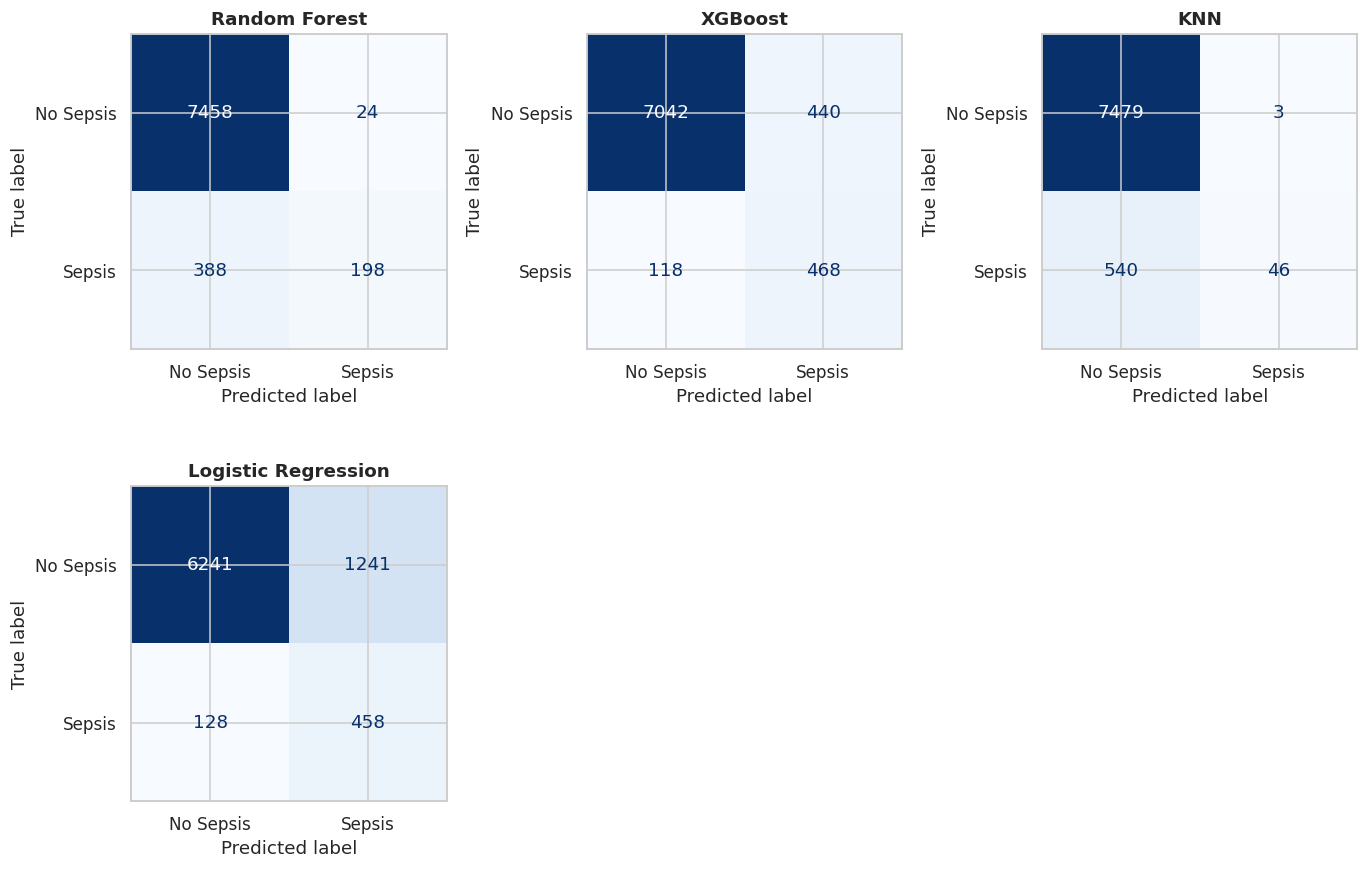

In [34]:
n_models = len(results)
n_cols = 3
n_rows = -(-n_models // n_cols)  # ceil division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4.2 * n_rows))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Sepsis', 'Sepsis']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)

# Hide any unused subplot axes (when n_models isn't a multiple of n_cols)
for ax in axes[n_models:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

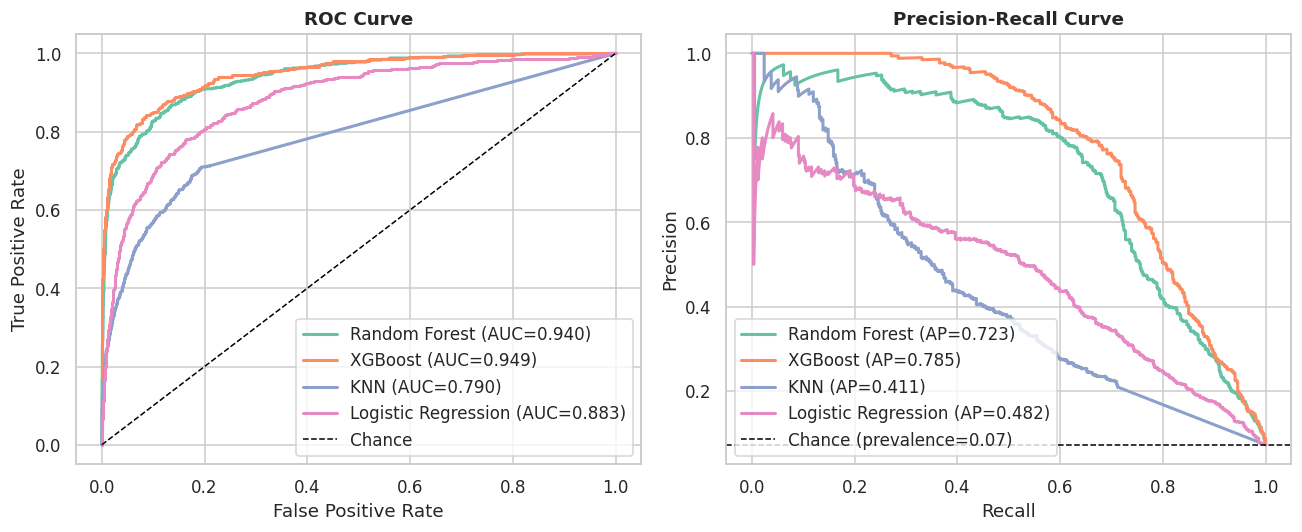

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = sns.color_palette('Set2', n_colors=len(results))
colors = dict(zip(results.keys(), palette))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", color=colors[name], lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['proba'])
    axes[1].plot(rec, prec, label=f"{name} (AP={res['avg_precision']:.3f})", color=colors[name], lw=2)
baseline = y_test.mean()
axes[1].axhline(baseline, color='k', ls='--', lw=1, label=f'Chance (prevalence={baseline:.2f})')
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 15. Feature Importance

KNN and SVM (RBF kernel) don't expose a native feature-importance/coefficient view, so this section covers the three models that do: Random Forest and XGBoost (impurity/gain-based importances) and Logistic Regression (absolute standardized coefficients — comparable across features since everything was scaled in `preprocessor`).

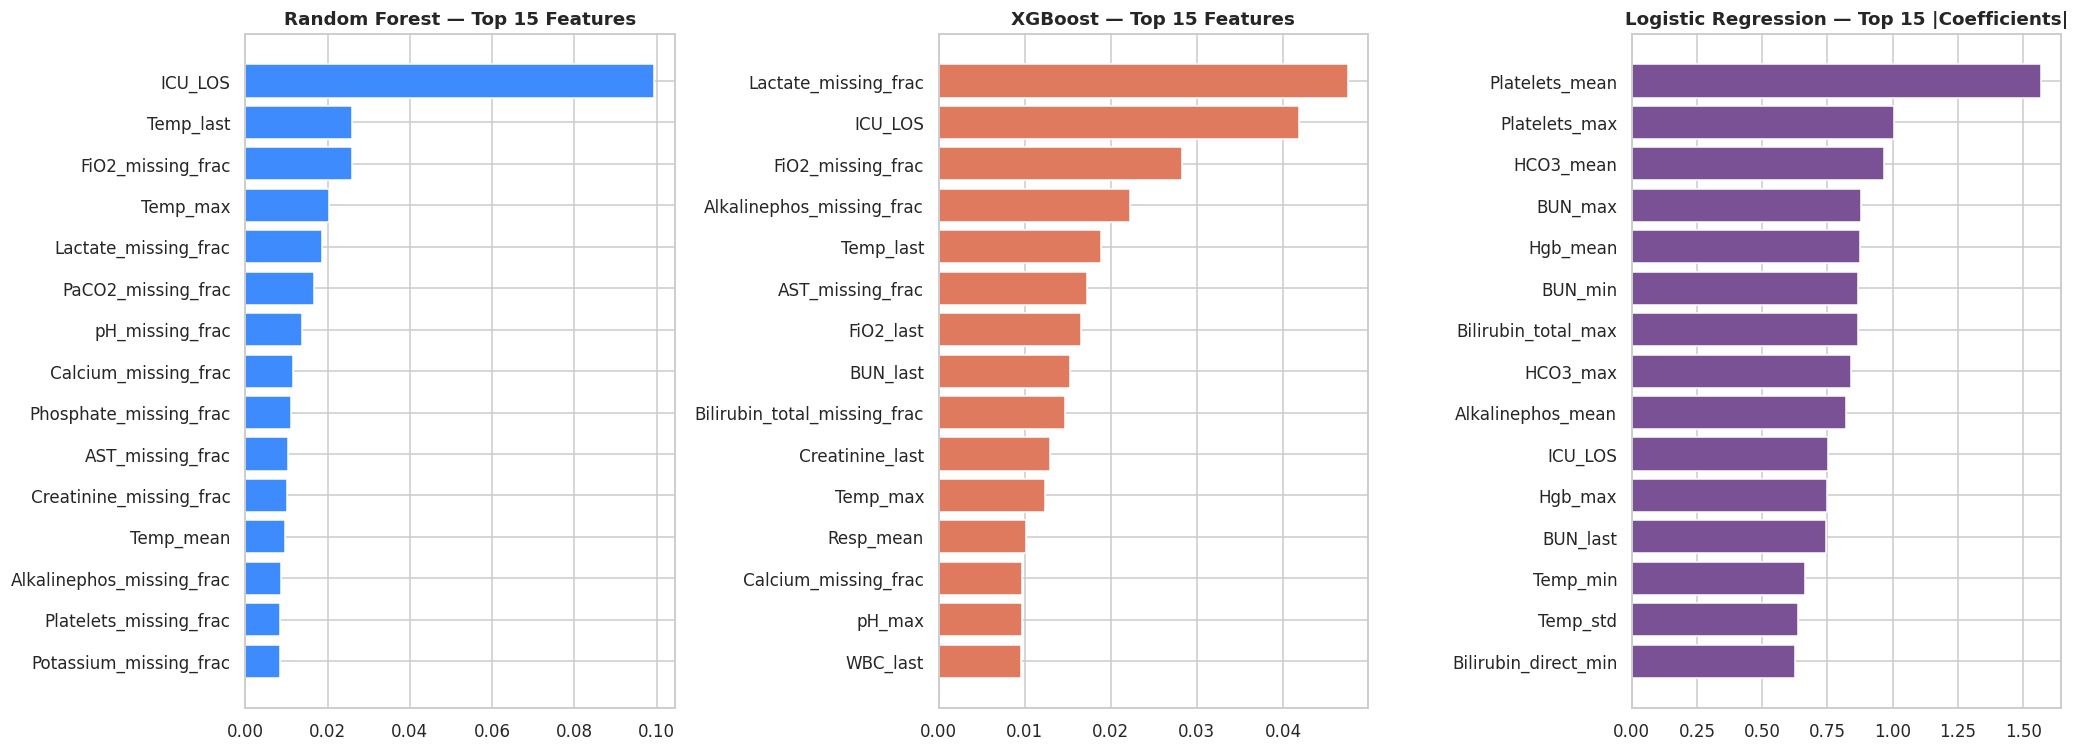

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))

rf_importances = pd.Series(
    rf_pipeline.named_steps['classifier'].feature_importances_, index=feature_cols
).sort_values(ascending=False).head(15)
axes[0].barh(rf_importances.index[::-1], rf_importances.values[::-1], color='#3d8bfd')
axes[0].set_title("Random Forest — Top 15 Features")

xgb_importances = pd.Series(
    xgb_pipeline.named_steps['classifier'].feature_importances_, index=feature_cols
).sort_values(ascending=False).head(15)
axes[1].barh(xgb_importances.index[::-1], xgb_importances.values[::-1], color='#e07a5f')
axes[1].set_title("XGBoost — Top 15 Features")

lr_importances = pd.Series(
    np.abs(lr_pipeline.named_steps['classifier'].coef_[0]), index=feature_cols
).sort_values(ascending=False).head(15)
axes[2].barh(lr_importances.index[::-1], lr_importances.values[::-1], color='#7a5195')
axes[2].set_title("Logistic Regression — Top 15 |Coefficients|")

plt.tight_layout()
plt.show()

## 16. Model Comparison Summary

In [36]:
summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, res['pred']),
        'Precision': precision_score(y_test, res['pred'], zero_division=0),
        'Recall': recall_score(y_test, res['pred'], zero_division=0),
        'F1-Score': f1_score(y_test, res['pred'], zero_division=0),
        'ROC-AUC': res['roc_auc'],
        'Average Precision': res['avg_precision'],
    })

# Kept as a plain DataFrame of fractions (0-1) so it stays usable for sorting,
# plotting, and programmatic comparisons; only the *display* below is %-formatted.
summary = pd.DataFrame(summary_rows).set_index('Model').sort_values('ROC-AUC', ascending=False)

summary.style.format('{:.2%}').background_gradient(cmap='Greens', axis=0)

NameError: name 'accuracy_score' is not defined

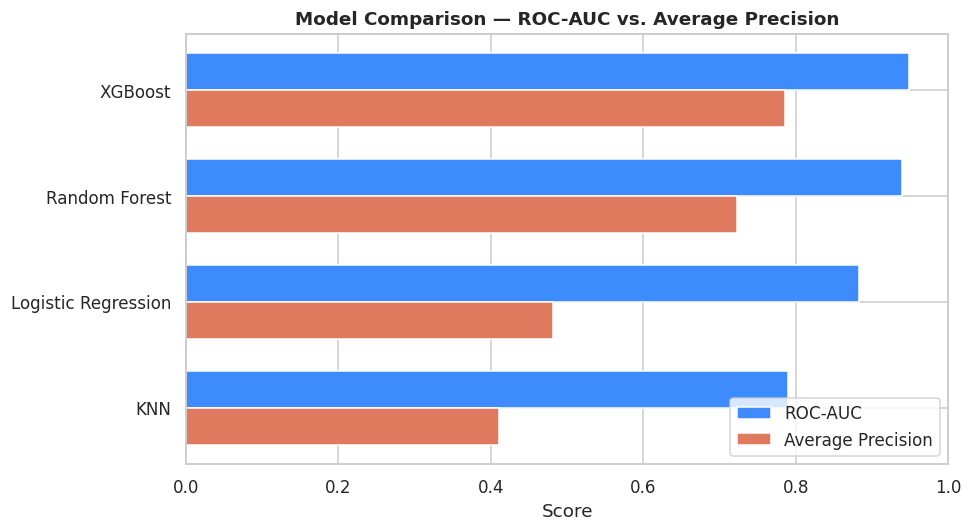

In [26]:
metrics_to_plot = ['Accuracy', 'ROC-AUC', 'Average Precision', 'F1-Score']
colors_metrics = ['#3d8bfd', '#e07a5f', '#2a9d8f', '#7a5195']

summary_sorted = summary.sort_values('ROC-AUC', ascending=True)
y_pos = np.arange(len(summary_sorted))
n_metrics = len(metrics_to_plot)
bar_h = 0.8 / n_metrics

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, metric in enumerate(metrics_to_plot):
    offset = (i - (n_metrics - 1) / 2) * bar_h
    ax.barh(y_pos + offset, summary_sorted[metric], height=bar_h, label=metric, color=colors_metrics[i])

ax.set_yticks(y_pos)
ax.set_yticklabels(summary_sorted.index)
ax.set_xlabel("Score")
ax.set_title("Model Comparison Across Metrics")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc='lower right', ncol=2)
plt.tight_layout()
plt.show()

## 17. Export the Final Pipeline

We export the best-performing pipeline (preprocessing **and** model bundled together) with `joblib`. Because preprocessing lives *inside* the pipeline, scoring a new patient at inference time is a single `.predict_proba()` call on raw aggregated features — no separate scaling/imputation code to keep in sync.

In [27]:
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best_pipeline = models[best_model_name]
print(f"Best model by ROC-AUC: {best_model_name}")

export_path = os.path.join(OUTPUT_DIR, "sepsis_pipeline.joblib")
joblib.dump({
    'pipeline': best_pipeline,
    'feature_cols': feature_cols,
    'model_name': best_model_name,
    'metrics': {k: v for k, v in results[best_model_name].items() if k in ('roc_auc', 'avg_precision')},
}, export_path)

print(f"Saved pipeline bundle to: {export_path}")


Best model by ROC-AUC: XGBoost
Saved pipeline bundle to: /content/outputs/sepsis_pipeline.joblib


In [28]:
import json
import numpy as np
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    roc_curve, precision_recall_curve, confusion_matrix
)

def export_eval(model_name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    cm = confusion_matrix(y_true, y_pred).tolist()
    report = classification_report(y_true, y_pred, target_names=["No Sepsis", "Sepsis"], output_dict=True)

    return {
        "model_name": model_name,
        "roc_auc": roc_auc_score(y_true, y_proba),
        "average_precision": average_precision_score(y_true, y_proba),
        "accuracy": report["accuracy"],
        "classification_report": report,   # precision/recall/f1/support per class
        "confusion_matrix": cm,             # [[TN, FP], [FN, TP]]
        "roc_curve": {"fpr": fpr.tolist(), "tpr": tpr.tolist()},
        "pr_curve": {"precision": prec.tolist(), "recall": rec.tolist()},
    }

# NOTE: named eval_export (not `results`) so this doesn't overwrite the `results` dict
# from the Evaluation section above, which Section 17 (Export Final Pipeline) and
# Section 18 (Inference Example) still rely on.
eval_export = {
    "xgboost": export_eval("XGBoost", y_test, xgb_pipeline.predict_proba(X_test)[:, 1]),
    "random_forest": export_eval("Random Forest", y_test, rf_pipeline.predict_proba(X_test)[:, 1]),
    "logistic_regression": export_eval("Logistic Regression", y_test, lr_pipeline.predict_proba(X_test)[:, 1]),
    "knn": export_eval("KNN", y_test, knn_pipeline.predict_proba(X_test)[:, 1]),
}

with open(os.path.join(OUTPUT_DIR, "model_evaluation.json"), "w") as f:
    json.dump(eval_export, f, indent=2)

In [29]:
import joblib

# Individual per-model exports (in addition to the single "best model" bundle saved above),
# useful if a downstream consumer wants to load a *specific* model rather than the winner.
joblib.dump(rf_pipeline, os.path.join(OUTPUT_DIR, "rf_pipeline.joblib"))
joblib.dump(xgb_pipeline, os.path.join(OUTPUT_DIR, "xgb_pipeline.joblib"))
joblib.dump(lr_pipeline, os.path.join(OUTPUT_DIR, "logreg_pipeline.joblib"))
joblib.dump(knn_pipeline, os.path.join(OUTPUT_DIR, "knn_pipeline.joblib"))

print(f"Saved individual model pipelines to: {OUTPUT_DIR}")

['knn_pipeline.jonlib']

## 17b. Export Feature Distributions (for downstream apps)

If you plan to build an app around this pipeline where a user only supplies a handful of values and the rest of the 208 engineered features need to be filled in automatically (e.g. a demo web UI), it's useful to have a lightweight summary of each feature's **real distribution** from the training data — without shipping the full dataset.

We store a **quantile grid** (values at the 0th, 5th, 10th, ..., 100th percentiles) per feature. To sample a realistic value later, draw `u ~ Uniform(0,1)` and linearly interpolate through the grid — this approximates the empirical distribution (including skew) using only 21 numbers per feature instead of the full column.

In [30]:
QUANTILE_LEVELS = np.linspace(0, 100, 21)  # 0%, 5%, 10%, ..., 100%

feature_distributions = {}
for col in feature_cols:
    s = X[col].dropna()
    if len(s) == 0:
        continue
    feature_distributions[col] = {
        'quantile_levels': QUANTILE_LEVELS.tolist(),
        'quantile_values': np.percentile(s, QUANTILE_LEVELS).tolist(),
        'mean': float(s.mean()),
        'std': float(s.std()) if len(s) > 1 else 0.0,
    }

dist_path = os.path.join(OUTPUT_DIR, "feature_distributions.json")
import json
with open(dist_path, 'w') as f:
    json.dump(feature_distributions, f)

print(f"Saved distributions for {len(feature_distributions)} features to: {dist_path}")


Saved distributions for 210 features to: /content/outputs/feature_distributions.json


## 18. Inference Example

Loading the exported bundle and scoring new patients. In production you'd run each new patient's hourly rows through the same `aggregate_patient_features()` function defined in Section 7 before calling `predict_proba`.

In [31]:
bundle = joblib.load(export_path)
loaded_pipeline = bundle['pipeline']
loaded_feature_cols = bundle['feature_cols']

sample_patients_X = X_test.iloc[:5][loaded_feature_cols]
sample_proba = loaded_pipeline.predict_proba(sample_patients_X)[:, 1]

inference_demo = pd.DataFrame({
    'PatientID': patient_df.loc[X_test.index[:5], 'PatientID'].values,
    'PredictedSepsisRisk': sample_proba.round(3),
    'ActualLabel': y_test.iloc[:5].values,
})
inference_demo


,PatientID,PredictedSepsisRisk,ActualLabel
0,p008039,0.363,0
1,p006365,0.417,0
2,p115536,0.984,1
3,p105824,0.943,1
4,p006308,0.995,1
